# Heat Equation (Physics informed)

## Mapping sparse data $u(x,y, t=t_1,t_2,...)$ to the solution space (L-shaped)

$$ u_t-{\mathcal{K}}\left(u_{x x}+u_{y y}\right) =0, \quad t \in[0,1], x, y \in[-0.5,0.5]$$ 

$$ u_{\text{bc}} = 0$$

$$ \text{Data}: \mathcal{K} \sim \text{logspace}(0.01, 0.2) ~~ \& ~~ u_{\text{ic}} \sim \text{GRFs}$$ 

Number of samples: 100*100

In [1]:
from flax import linen as nn
from typing import Sequence, Tuple
import jax
import jax.numpy as jnp
from torch.utils import data
from functools import partial
import time
import optax
import scipy.io
import os
import matplotlib.pyplot as plt
import shutil
import pandas as pd
from jax import jvp
import pickle
from sklearn import metrics
from termcolor import colored
import random
import numpy as np
from scipy.interpolate import griddata
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator, ScalarFormatter

In [2]:
## All inputs

path_data = '/home/droysar1/scr4_sgoswam4/Dibakar/Diffusion_project/L_shape_data/L_shape_heat_eqn_K_sweep3'

seed = 46
n_train = 8000
batch_size = 75
n_sensors = 40*11 # (x*y, t)
branch_layers = [32, 32, 32]
h_layers = [32, 32, 32]
branch_input_features = 1
trunk_layers = [32, 32, 32]
trunk_input_features = 3
hidden_dim = 70
p_test = 100
p_res_train = 2000
result_dir = './'
epochs = 80000
vis_iter = 1000
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9


In [3]:
# Data loading

sensor_data = jnp.array(jnp.load(os.path.join(path_data, 'sensor_data.npy')))
sensor_positions = jnp.array(jnp.load(os.path.join(path_data, 'sensor_positions.npy')))
sensor_times = jnp.array(jnp.load(os.path.join(path_data, 'sensor_times.npy')))

full_solution = jnp.array(jnp.load(os.path.join(path_data, 'output_data.npy')))
full_solution_mesh = jnp.array(jnp.load(os.path.join(path_data, 'mesh_points.npy')))
time_steps = jnp.array(jnp.load(os.path.join(path_data, 'time_steps.npy')))

initial_con = jnp.array(jnp.load(os.path.join(path_data, 'input_data.npy')))

k_all = jnp.array(jnp.load(os.path.join(path_data, 'ks.npy')))




print("sensor_data: ", str(sensor_data.shape))
print("sensor_positions: ", str(sensor_positions.shape))
print("sensor_times: ", str(sensor_times.shape))
print("full_solution: ", str(full_solution.shape))
print("full_solution_mesh: ", str(full_solution_mesh.shape))
print("time_steps: ", str(time_steps.shape))
print("initial_con: ", str(initial_con.shape))
print("k_all: ", str(k_all.shape))



samples, sensors, timepoints = sensor_data.shape
reshaped_sensor_data = sensor_data.transpose(0, 2, 1).reshape(samples, sensors * timepoints)
positions_tiled = np.tile(sensor_positions, (len(sensor_times), 1))
times_repeated = np.repeat(sensor_times, len(sensor_positions)).reshape(-1, 1)
sensor_coordinates = np.hstack((positions_tiled, times_repeated))

#----- Reshaped --------#
print("#----- Reshaped --------#")
print("reshaped_sensor_data: ", str(reshaped_sensor_data.shape))
print("sensor_coordinates: ", str(sensor_coordinates.shape))

samples, sensors, timepoints = full_solution.shape
reshaped_solution_data = full_solution.transpose(0, 2, 1).reshape(samples, sensors * timepoints)
full_solution_mesh_tiled = np.tile(full_solution_mesh, (len(time_steps), 1))
times_repeated = np.repeat(time_steps, len(full_solution_mesh)).reshape(-1, 1)
full_solution_coordinates = np.hstack((full_solution_mesh_tiled, times_repeated))

#----- Reshaped --------#
print("#----- Reshaped --------#")
print("reshaped_solution_data: ", str(reshaped_solution_data.shape))
print("full_solution_coordinates: ", str(full_solution_coordinates.shape))


2025-11-11 00:10:16.247117: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.68. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


sensor_data:  (10000, 40, 11)
sensor_positions:  (40, 2)
sensor_times:  (11,)
full_solution:  (10000, 833, 101)
full_solution_mesh:  (833, 2)
time_steps:  (101,)
initial_con:  (10000, 833)
k_all:  (10000,)
#----- Reshaped --------#
reshaped_sensor_data:  (10000, 440)
sensor_coordinates:  (440, 3)
#----- Reshaped --------#
reshaped_solution_data:  (10000, 84133)
full_solution_coordinates:  (84133, 3)


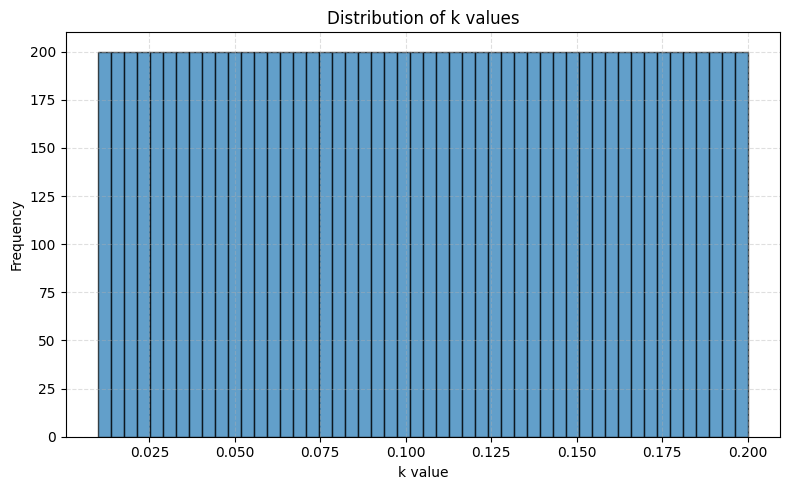

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming k_all is a NumPy array of shape (10000,)
def plot_k_distribution(k_all, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(k_all, bins=bins, color='#1f77b4', edgecolor='black', alpha=0.7)
    plt.xlabel("k value")
    plt.ylabel("Frequency")
    plt.title("Distribution of k values")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    
plot_k_distribution(k_all)

In [5]:
# Shuffle the data
indices = np.arange(reshaped_sensor_data.shape[0])
np.random.shuffle(indices)

shuffled_sensor_data = reshaped_sensor_data[indices]
shuffled_solution_data = reshaped_solution_data[indices]
shuffled_k_data = k_all[indices]
shuffled_initial_con = initial_con[indices]

# Split
X_train = shuffled_sensor_data[:n_train]
X_test = shuffled_sensor_data[n_train:]

y_train = shuffled_sensor_data[:n_train]
y_test = shuffled_solution_data[n_train:]

k_train = shuffled_k_data[:n_train]
k_test = shuffled_k_data[n_train:]

initial_con_train = shuffled_initial_con[:n_train]
initial_con_test = shuffled_initial_con[n_train:]

print("X_train: ", str(X_train.shape))
print("X_test: ", str(X_test.shape))

print("y_train: ", str(y_train.shape))
print("y_test: ", str(y_test.shape))

print("k_train: ", str(k_train.shape))
print("k_test: ", str(k_test.shape))

print("initial_con_train: ", str(initial_con_train.shape))
print("initial_con_test: ", str(initial_con_test.shape))

X_train:  (8000, 440)
X_test:  (2000, 440)
y_train:  (8000, 440)
y_test:  (2000, 84133)
k_train:  (8000,)
k_test:  (2000,)
initial_con_train:  (8000, 833)
initial_con_test:  (2000, 833)


In [6]:
# Data Generator
class DataGenerator(data.Dataset):
    def __init__(self, u_data, y, s, k, batch_size, gen_key):
        self.u_data = u_data
        self.y = y
        self.s = s
        self.k = k
        self.N = u_data.shape[0]
        self.batch_size = batch_size
        self.key = gen_key

    def __getitem__(self, index):
        """Generate one batch of data"""
        self.key, subkey = jax.random.split(self.key)
        inputs, outputs = self.__data_generation(subkey)
        return inputs, outputs

    @partial(jax.jit, static_argnums=(0,))
    def __data_generation(self, key_i):
        """Generates data containing batch_size samples"""
        idx = jax.random.choice(key_i, self.N, (self.batch_size,), replace=False)
        s = self.s[idx, :]
        y = self.y[:, :]
        u_data = self.u_data[idx]
        k = self.k[idx]
        # Construct batch
        inputs = (u_data, y, k)
        outputs = s
        return inputs, outputs

In [7]:
"""# Data generation for each sample"""
def generate_one_res_training_data(initial_con, key, p=2500):
    p_grid = int(jnp.cbrt(p))  # Base number along each axis

    # Generate sorted 1D points
    t_res_i = jnp.sort(jax.random.uniform(key, shape=(p_grid,), minval=0.0, maxval=0.25))
    x_res_i = jnp.sort(jax.random.uniform(key, shape=(p_grid,), minval=-0.5, maxval=0.5))
    y_res_i = jnp.sort(jax.random.uniform(key, shape=(p_grid,), minval=-0.5, maxval=0.5))

    # Create 3D meshgrid
    t_res, x_res, y_res = jnp.meshgrid(t_res_i, x_res_i, y_res_i, indexing='ij')

    # Flatten grids
    t_flat = t_res.flatten()
    x_flat = x_res.flatten()
    y_flat = y_res.flatten()

    # Mask out the top-right square: x > 0 and y > 0
    mask = jnp.logical_not(jnp.logical_and(x_flat > 0.0, y_flat > 0.0))

    # Apply mask
    t_filtered = t_flat[mask]
    x_filtered = x_flat[mask]
    y_filtered = y_flat[mask]

    # Stack into coordinates shape (N, 3)
    cord = jnp.stack([x_filtered, y_filtered, t_filtered], axis=-1)

    sol = jnp.zeros((cord.shape[0],))

    return initial_con, cord, sol

In [8]:
"""# Data generation for each sample"""

key = jax.random.PRNGKey(seed)
keys = jax.random.split(key, 6)

print("----Coll----")
# Residual data
ics_res_train, cord_res_train, s_res_train = jax.vmap(generate_one_res_training_data, in_axes=(0, None, None))(initial_con_train, key, p_res_train)

print("s_res_train: ", str(s_res_train.shape))  # (25, 4080)
print("ics_res_train: ", str(ics_res_train.shape)) # (25, 833)
print("cord_res_train: ", str(cord_res_train.shape)) # Expected: (25, 4080, 3)

data_dataset = DataGenerator(X_train, sensor_coordinates, y_train, k_train, batch_size, keys[0])

# Create data generators

res_dataset = DataGenerator(X_train, cord_res_train, s_res_train, k_train, batch_size, keys[2])


----Coll----
s_res_train:  (8000, 1536)
ics_res_train:  (8000, 833)
cord_res_train:  (8000, 1536, 3)


In [9]:
class DeepONet(nn.Module):
    branch_layers: Sequence[int]
    trunk_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, branch_x, trunk_x):

        init = nn.initializers.glorot_normal()

        if branch_x.ndim == 1:
            branch_x = jnp.expand_dims(branch_x, axis=-1)

        for i, fs in enumerate(self.branch_layers[:-1]):
            branch_x = nn.Dense(fs, kernel_init=init, name=f"branch_{i}")(branch_x)
            branch_x = nn.activation.tanh(branch_x)
        branch_x = nn.Dense(self.branch_layers[-1], name=f"branch_{i+1}", kernel_init=init)(branch_x)

        if trunk_x.ndim == 1:
            trunk_x = jnp.expand_dims(trunk_x, axis=0)

        for i, fs in enumerate(self.trunk_layers):
            trunk_x = nn.Dense(fs, kernel_init=init, name=f"trunk_{i}")(trunk_x)
            trunk_x = nn.activation.tanh(trunk_x)

        # [x_num, p]

        # Compute the final output
        # Input shapes:
        # branch: [batch_size, p]
        # trunk: [x_num, p]
        # output: [batch_size, x_num]
        result = jnp.einsum('ij,kj->ik', branch_x, trunk_x)

        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        result += bias

        return result

In [10]:
class INV_MLP(nn.Module):
    h_layers: Sequence[int]
    output_dim: int = 1

    @nn.compact
    def __call__(self, x, training=False):
        init = nn.initializers.glorot_normal()
        # print(finput shape: {x.shape}")  # Debugging line
        for i, features in enumerate(self.h_layers):
            x = nn.Dense(features, kernel_init=init)(x)
            x = nn.silu(x)
        
        # Add bias
        bias = self.param('output_bias', nn.initializers.zeros, (self.output_dim,))
        x += bias
        return x

In [11]:
"""# Helper functions"""

@partial(jax.jit)
def mse(y_true, y_pred):
    return jnp.mean(jnp.square(y_true - y_pred))

@partial(jax.jit)
def mse_single(y_pred):
    return jnp.mean(jnp.square(y_pred))

@partial(jax.jit, static_argnums=(0,))
def apply_net(model_fn, params, branch_input, *trunk_in):
    if len(trunk_in) == 1:
        trunk_input = trunk_in[0]
    else:
        trunk_input = jnp.stack(trunk_in, axis=-1)
    out = model_fn(params, branch_input, trunk_input)

    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out

@partial(jax.jit, static_argnums=(0,))
def apply_net_k(model_inv_fn, params, input_u):

    out = model_inv_fn(params, input_u)

    if out.shape[1]==1:
        out = jnp.squeeze(out, axis=1)
    return out


@partial(jax.jit, static_argnums=(0, 1, 2, 3))
def step(optimizer, loss_fn, model_inv_fn, model_fn, opt_state, params_step, res_batch, data_batch, key):
    loss, gradient = jax.value_and_grad(loss_fn, argnums=2)(model_fn, model_inv_fn, params_step, res_batch, data_batch, key)
    updates, opt_state = optimizer.update(gradient, opt_state)
    params_step = optax.apply_updates(params_step, updates)

    return loss, params_step, opt_state

In [12]:
"""# Loss functions"""

def loss_res_single_sample(model_fn_nu, model_fn, params_nu, params_loaded,
                           u_data_single, t, x, y, key):
    """Compute residual + KL loss for one u_data sample."""
    u_data_single = u_data_single[None, :]  # shape (1, latent_dim)

    # Define PDE function
    def f(x, y, t):
        return apply_net(model_fn, params_loaded, u_data_single, x, y, t)

    # Forward pass
    s = f(x, y, t)

    # Predict D (D) distribution parameters
    k_pred_all = apply_net_k(model_fn_nu, params_nu, u_data_single)
    # print("k_pred_all: ", k_pred_all.shape)
    k_mean_raw, k_logstd_raw = k_pred_all[:,0], k_pred_all[:,1]

    # Ensure ν_mean > 0
    k_mean = jax.nn.softplus(k_mean_raw)

    # Cap std to avoid explosion
    k_std_raw = jnp.exp(k_logstd_raw)
    k_std = jnp.minimum(k_std_raw, 0.3 * k_mean)
    # k_std = k_std_raw
    

    # Reparameterization trick
    eps = jax.random.normal(key, shape=())
    k_sampled = k_mean + eps * k_std

    # Compute derivatives
    _, s_x = jax.jvp(lambda x: f(x, y, t), (x,), (jnp.ones_like(x),))
    _, s_t = jax.jvp(lambda t: f(x, y, t), (t,), (jnp.ones_like(t),))
    _, s_xx = jax.jvp(lambda x: jax.jvp(lambda x: f(x, y, t), (x,), (jnp.ones_like(x),))[1],
                      (x,), (jnp.ones_like(x),))
    _, s_yy = jax.jvp(lambda y: jax.jvp(lambda y: f(x, y, t), (y,), (jnp.ones_like(y),))[1], (y,), (jnp.ones_like(y),))
    
    # print("k_sampled: ", k_sampled.shape)
    # print("s_t: ", s_t.shape)
    # print("s_xx: ", s_xx.shape)
    # print("s_yy: ", s_yy.shape)
    
    pred = s_t - k_sampled * (s_xx + s_yy)

    # Residual loss
    residual_loss = mse_single(pred)

    # KL regularization
    prior_mean, prior_std = 0.09, 0.06#0.015
    kl_loss = 0.5 * (
        (k_std / prior_std)**2 +
        ((k_mean - prior_mean) / prior_std)**2 -
        1 + 2 * jnp.log(prior_std) - 2 * jnp.log(k_std)
    )

    return residual_loss + 0.001 * kl_loss

def loss_res(model_fn, model_inv_fn, params, res_batch, key):
    """Vectorized probabilistic residual loss (Burgers' PDE)."""
    inputs, _ = res_batch
    u_data, cord, _ = inputs
    
    params_loaded, params_inv = params
    
    # Fixed t, x grid (same for all samples)
    x = cord[0, :, 0]
    y = cord[0, :, 1]
    t = cord[0, :, 2]

    # Random keys for each sample
    keys = jax.random.split(key, u_data.shape[0])
    
    # print(u_data.shape)
    # print(keys.shape)
    
    # Vectorized computation over (u_data[i], k[i])
    losses = jax.vmap(
        lambda u, k: loss_res_single_sample(
            model_inv_fn, model_fn, params_inv, params_loaded, u, t, x, y, k
        )
    )(u_data, keys)

    return jnp.mean(losses)


def loss_data(model_fn, params, data_batch):

    inputs, outputs = data_batch
    u_data, cord, _ = inputs
    
    params_sol, params_inv = params
    
    x = cord[:, 0]
    y = cord[:, 1]
    t = cord[:, 2]

    s_pred = apply_net(model_fn, params_sol, u_data, x, y, t)


    loss = mse(outputs, s_pred)
    return loss

def loss_fn(model_fn, model_inv_fn, params,  res_batch, data_batch, key):
    loss_res_i = loss_res(model_fn, model_inv_fn, params, res_batch, key)
    loss_data_i = loss_data(model_fn, params, data_batch)
    loss_value = 1.0*loss_data_i + 1.0*loss_res_i 
    return loss_value

In [13]:
"""# Initialize the model"""

# Initialize model and params
# make sure trunk_layers and branch_layers are lists
trunk_layers = [trunk_layers] if isinstance(trunk_layers, int) else trunk_layers

branch_layers = [branch_layers] if isinstance(branch_layers, int) else branch_layers

h_layers = [h_layers] if isinstance(h_layers, int) else h_layers


# add output features to trunk and branch layers
trunk_layers = trunk_layers + [hidden_dim]
branch_layers = branch_layers + [hidden_dim]
h_layers = h_layers + [2]


# Convert list to tuples
trunk_layers = tuple(trunk_layers)
branch_layers = tuple(branch_layers)
h_layers = tuple(h_layers)

num_outputs = 1
model = DeepONet(branch_layers, trunk_layers, num_outputs)

# model function
model_fn = jax.jit(model.apply)

num_outputs = 1
model_inv = INV_MLP(h_layers, num_outputs)

params_inv = model_inv.init(key, jnp.ones(shape=(1, n_sensors * branch_input_features)))

# Print model from parameters
print('--- model_inv_summary ---')
# count total params
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params_inv))
print(f'total params: {total_params}')

# model function
model_inv_fn = jax.jit(model_inv.apply)

2025-11-11 00:10:20.921694: E external/xla/xla/service/hlo_lexer.cc:438] Failed to parse int literal: 894515288310727292233


--- model_inv_summary ---
total params: 16291


In [14]:
"""# model save function"""

def save_model_params(params, result_dir, filename='model_params.pkl'):
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)

    save_path = os.path.join(result_dir, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(result_dir, filename='model_params.pkl'):
    load_path = os.path.join(result_dir, filename)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params

# Usage:
save = True

In [15]:
save = True
params_loaded = load_model_params('/home/droysar1/scr4_sgoswam4/Dibakar/INV_DON/2D_heat_L_dist/solution_op2_32')

print("Loaded best model parameters")

params = (params_loaded, params_inv)


Loaded best model parameters


In [16]:
"""# Test error function"""

def loss_test_l2_error(model_fn, model_inv_fn, params, X_test, y_test, full_solution_coordinates, k_test, return_data=False):

    x = full_solution_coordinates[:,0]
    y = full_solution_coordinates[:,1]
    t = full_solution_coordinates[:,2]
    
    params_sol, params_inv = params

    def ff_net(x, y, t):
        s_pred = apply_net(model_fn, params_sol, X_test, x, y, t)
        return s_pred

    s_pred = ff_net(x, y, t)

    loss_test = mse(y_test, s_pred)

    def l2_norm_error(a, b):
        """Calculate L2 norm error between two 2D arrays."""
        return jnp.linalg.norm(a - b)/jnp.linalg.norm(a)

    l2_error = jnp.mean(jax.vmap(l2_norm_error)(y_test, s_pred))

    if return_data:
        start = time.time()
        
        k_pred = apply_net_k(model_inv_fn, params_inv, X_test)
        
        end = time.time()

        print("Runtime:", end - start, "seconds")
        
        abs_err_k = jnp.abs(k_test - k_pred)
        
        return loss_test, l2_error, s_pred, k_pred, abs_err_k
    else:
        return loss_test, l2_error

In [17]:
"""# Define optimiser"""

# Define optimizer with optax (ADAM)
# optimizer

lr_scheduler = optax.exponential_decay(lr, transition_steps, decay_rate)

# lr_scheduler = optax.constant_schedule(1e-3)

optimizer = optax.adam(learning_rate=lr_scheduler)
opt_state = optimizer.init(params)

# Data
res_data = iter(res_dataset)
data_data = iter(data_dataset)


# create dir for saving results
result_dir = os.path.join(os.getcwd(), os.path.join(result_dir, f"inv_op_{seed}"))
log_file = os.path.join(result_dir, 'log.csv')
# Create directory
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
if os.path.exists(os.path.join(result_dir, 'vis')):
    shutil.rmtree(os.path.join(result_dir, 'vis'))
if os.path.exists(log_file):
    os.remove(log_file)


with open(log_file, 'a') as f:
    f.write('epoch,loss,loss_res_value,loss_data_value,l2err_test,loss_test,runtime\n')

In [18]:


"""# Training loop"""

# Iterations
epochs = epochs  # Assuming 'epochs' is defined elsewhere
epochs = 120000
log_iter = 1000
best_mse = float('inf')  # Initialize with infinity
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_0.pkl')
print("Saved initial model at iteration 0")
# Training loop
for it in range(epochs):
    if it == 1:
        # start timer and exclude first iteration (compile time)
        start = time.time()
    # Fetch data
    res_batch = next(res_data)
    data_batch = next(data_data)

    # Do Step

    loss, params, opt_state = step(optimizer, loss_fn, model_inv_fn, model_fn, opt_state,
                                   params, res_batch, data_batch, key)
    if it % log_iter == 0:
        loss = loss_fn(model_fn, model_inv_fn, params, res_batch, data_batch, key)
        loss_res_value = loss_res(model_fn, model_inv_fn, params, res_batch, key)
        loss_data_value = loss_data(model_fn, params, data_batch)

        # loss_test, rel_error = loss_test_l2_error(model_fn, params_loaded, data_output, u_sol_test, return_data=False)
        if loss <  best_mse:
            best_mse = loss
            # Save the model as it's the best so far
            # params = (params_loaded, params_nu)
            save_model_params(params, result_dir, filename='model_params_best.pkl')
            print(f"New best model saved at iteration {it} with test MSE: {loss:.2e}")

        # get runtime
        if it == 0:
            runtime = 0
        else:
            runtime = time.time() - start

        # Print losses
        print(f"Iteration {it+1}/{epochs}")
        print(f"Trian_loss: {loss:.2e}, "
              f"loss_res: {loss_res_value:.2e}, loss_data: {loss_data_value:.2e} , runtime: {runtime:06.2f}")

        # Save results
        with open(log_file, 'a') as f:
            f.write(f'{it+1}, {loss}, '
                    f'{loss_res_value}, {loss_data_value}, {runtime}\n')

# Save results
runtime = time.time() - start
# Save initial model at 0th iteration
save_model_params(params, result_dir, filename='model_params_last.pkl')
print("Saved model at end of training")
with open(log_file, 'a') as f:
    f.write(f'{it + 1}, {loss}, '
            f' {loss_res_value}, {loss_data_value}, {runtime}\n')

Saved initial model at iteration 0
New best model saved at iteration 0 with test MSE: 1.15e-01
Iteration 1/120000
Trian_loss: 1.15e-01, loss_res: 7.03e-02, loss_data: 4.48e-02 , runtime: 000.00
New best model saved at iteration 1000 with test MSE: 3.30e-02
Iteration 1001/120000
Trian_loss: 3.30e-02, loss_res: 7.95e-03, loss_data: 2.50e-02 , runtime: 002.09
New best model saved at iteration 2000 with test MSE: 2.17e-02
Iteration 2001/120000
Trian_loss: 2.17e-02, loss_res: 2.79e-03, loss_data: 1.89e-02 , runtime: 004.05
New best model saved at iteration 3000 with test MSE: 1.75e-02
Iteration 3001/120000
Trian_loss: 1.75e-02, loss_res: 1.41e-03, loss_data: 1.61e-02 , runtime: 005.97
Iteration 4001/120000
Trian_loss: 2.17e-02, loss_res: 1.01e-03, loss_data: 2.07e-02 , runtime: 007.86
Iteration 5001/120000
Trian_loss: 2.02e-02, loss_res: 1.46e-03, loss_data: 1.88e-02 , runtime: 009.74
Iteration 6001/120000
Trian_loss: 1.95e-02, loss_res: 2.57e-03, loss_data: 1.69e-02 , runtime: 011.62
Itera

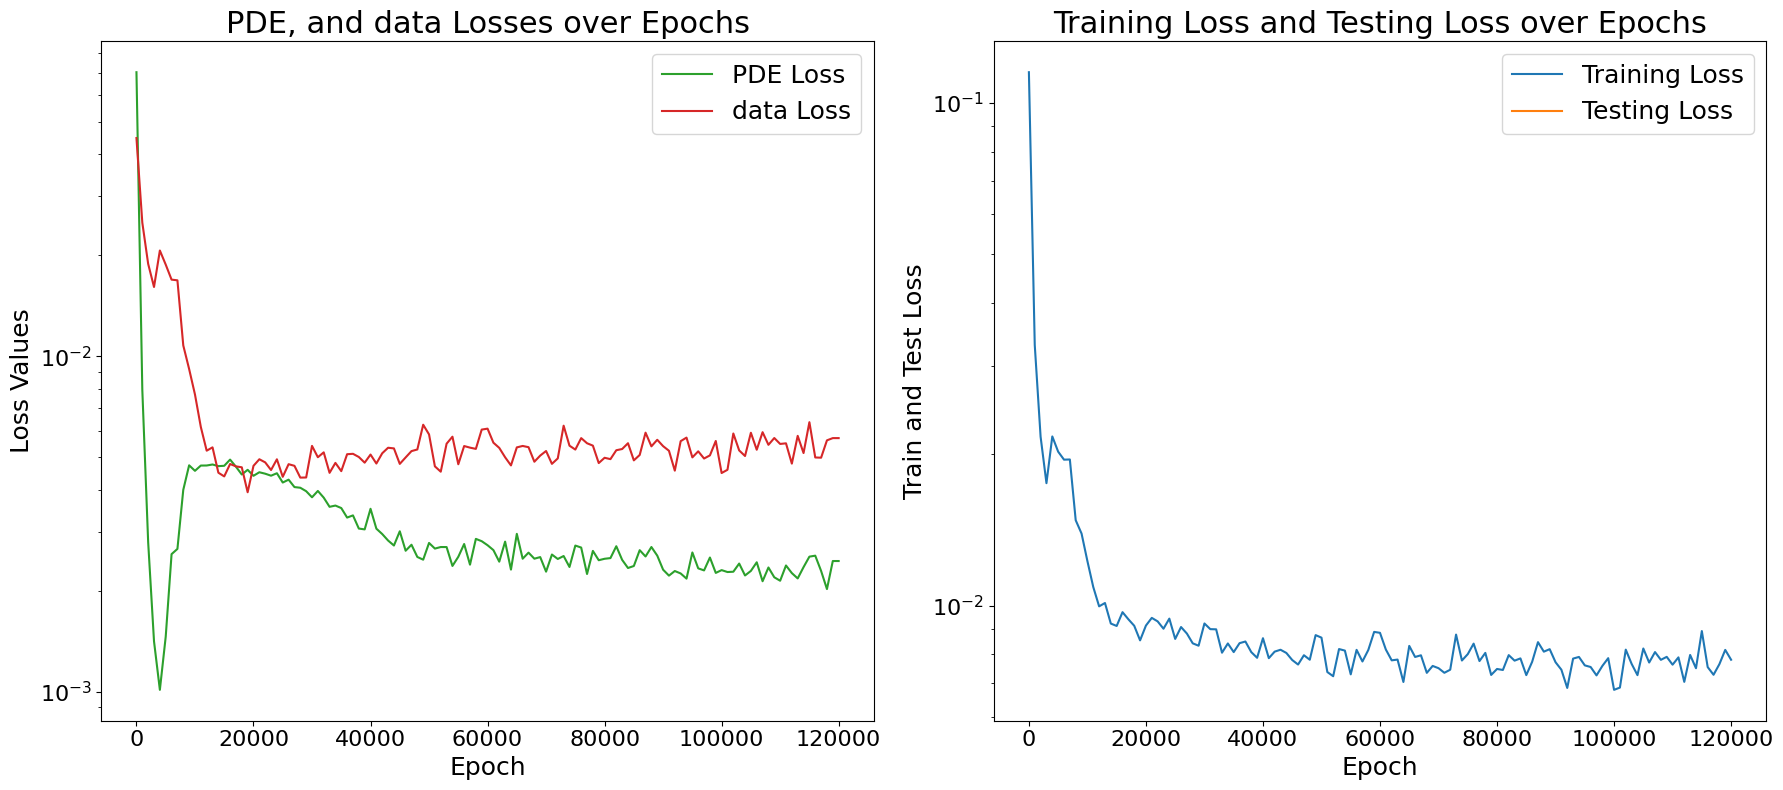

Plots saved to /scratch4/sgoswam4/Dibakar/INV_DON/2D_heat_L_dist/./inv_op_46/train_and_test_loss_plots.png


In [19]:
"""# Loss plots"""

# Read the CSV file
csv_file = os.path.join(result_dir, "log.csv")  # Assuming the file is named "log.csv"
df = pd.read_csv(csv_file)

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=100)

# Set color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left plot: epoch vs loss_data, and loss_res_value
ax1.plot(df['epoch'], df['loss_res_value'], label='PDE Loss', color=colors[2], linestyle='-')
ax1.plot(df['epoch'], df['loss_data_value'], label='data Loss', color=colors[3], linestyle='-')

ax1.set_yscale("log")
ax1.set_xlabel('Epoch', fontsize=18)
ax1.set_ylabel('Loss Values', fontsize=18)
ax1.set_title('PDE, and data Losses over Epochs', fontsize=22)
ax1.legend(loc='best', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Right plot: epoch vs loss and l2err_val
ax2.plot(df['epoch'], df['loss'], label='Training Loss', color=colors[0], linestyle='-')
ax2.plot(df['epoch'], df['loss_test'], label='Testing Loss', color=colors[1], linestyle='-')
ax2.set_yscale("log")
ax2.set_xlabel('Epoch', fontsize=18)
ax2.set_ylabel('Train and Test Loss', fontsize=18)
ax2.set_title('Training Loss and Testing Loss over Epochs', fontsize=22)
ax2.legend(loc='best', fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=16)  # Set axis ticks font size

# Adjust layout and save the figure
plt.tight_layout()
output_file = os.path.join(result_dir, "train_and_test_loss_plots.png")
plt.savefig(output_file, dpi=100)
plt.show()
plt.close()

print(f"Plots saved to {output_file}")

In [20]:
sensor_positions, sensor_times

(Array([[-0.5    , -0.5    ],
        [-0.34375, -0.5    ],
        [-0.5    , -0.34375],
        [-0.34375, -0.34375],
        [-0.15625, -0.5    ],
        [ 0.     , -0.5    ],
        [-0.15625, -0.34375],
        [ 0.     , -0.34375],
        [-0.5    , -0.15625],
        [-0.34375, -0.15625],
        [-0.5    ,  0.     ],
        [-0.34375,  0.     ],
        [-0.15625, -0.15625],
        [ 0.     , -0.15625],
        [-0.15625,  0.     ],
        [ 0.     ,  0.     ],
        [ 0.15625, -0.5    ],
        [ 0.15625, -0.34375],
        [ 0.34375, -0.5    ],
        [ 0.5    , -0.5    ],
        [ 0.34375, -0.34375],
        [ 0.5    , -0.34375],
        [ 0.15625, -0.15625],
        [ 0.15625,  0.     ],
        [ 0.34375, -0.15625],
        [ 0.5    , -0.15625],
        [ 0.34375,  0.     ],
        [ 0.5    ,  0.     ],
        [-0.5    ,  0.15625],
        [-0.34375,  0.15625],
        [-0.15625,  0.15625],
        [ 0.     ,  0.15625],
        [-0.5    ,  0.34375],
        [-

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ============================================
# SIMPLE SOLVER VERIFICATION
# ============================================

# Select a test sample
sample_idx = 200

# Get ground truth data
actual_k = k_all[sample_idx]
initial_condition_1d = initial_con[sample_idx]  # (833,)

print(f"Testing sample {sample_idx}")
print(f"Actual k: {actual_k:.6f}")
print(f"Initial condition range: [{initial_condition_1d.min():.6f}, {initial_condition_1d.max():.6f}]")
print(f"Mesh range: X=[{full_solution_mesh[:, 0].min():.3f}, {full_solution_mesh[:, 0].max():.3f}], "
      f"Y=[{full_solution_mesh[:, 1].min():.3f}, {full_solution_mesh[:, 1].max():.3f}]")

# ============================================
# SETUP SOLVER GRID
# ============================================
Nx, Ny = 60, 60
x_grid = np.linspace(-0.5, 0.5, Nx)
y_grid = np.linspace(-0.5, 0.5, Ny)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

# Interpolate initial condition
u0_grid = griddata(
    full_solution_mesh,
    initial_condition_1d,
    (X_grid, Y_grid),
    method='linear',
    fill_value=0.0
)

# Apply L-shape mask (remove top-right: x >= 0 AND y >= 0)
u0_grid[(X_grid >= 0.0) & (Y_grid >= 0.0)] = 0.0
u0_grid[0, :] = u0_grid[-1, :] = u0_grid[:, 0] = u0_grid[:, -1] = 0.0

print(f"Interpolated u0: min={u0_grid.min():.6f}, max={u0_grid.max():.6f}, mean={u0_grid.mean():.6f}")

# ============================================
# RUN SOLVER WITH ACTUAL K
# ============================================
T = float(sensor_times[-1])
dt_solver = 1e-3

print(f"\nRunning solver with actual k={actual_k:.6f}")
print(f"T={T}, dt={dt_solver}, steps={int(T/dt_solver)}")

X, Y, sol_predicted, mask = heat2D_Lshape_solver(
    u0_grid, actual_k, T=T, dt=dt_solver, Nx=Nx, Ny=Ny,
    Lx=1.0, Ly=1.0, x_min=-0.5, y_min=-0.5
)

print(f"\nSolver output: {sol_predicted.shape}")
print(f"Solution range: [{sol_predicted.min():.6f}, {sol_predicted.max():.6f}]")

# ============================================
# COMPARE WITH GROUND TRUTH AT SENSOR TIMES
# ============================================
print("\n" + "="*60)
print("COMPARING SOLVER WITH GROUND TRUTH")
print("="*60)

# Prepare for interpolation
valid_mask = ~((X >= 0.0) & (Y >= 0.0))
valid_grid_points = np.column_stack([X[valid_mask].ravel(), Y[valid_mask].ravel()])

# Get ground truth full solution
# Assuming full_solution has shape (10000, 833, n_timesteps) or similar
# You'll need to adjust this based on your actual data structure
ground_truth_solution = full_solution[sample_idx]  # Adjust indexing as needed

print(f"\nGround truth solution shape: {ground_truth_solution.shape}")

# Compare at each sensor time
for t_idx, t in enumerate(sensor_times):
    step_idx = int(np.round(t / dt_solver))
    step_idx = min(step_idx, sol_predicted.shape[0] - 1)
    
    # Predicted solution at time t
    sol_pred_t = sol_predicted[step_idx]
    
    # Ground truth at time t (interpolated to grid)
    # Adjust this based on how your ground truth is stored
    if ground_truth_solution.ndim == 2:  # (833, n_times)
        gt_values_t = ground_truth_solution[:, t_idx]
    else:  # Adjust as needed
        gt_values_t = ground_truth_solution[t_idx]
    
    # Interpolate ground truth to solver grid
    sol_gt_t = griddata(
        full_solution_mesh,
        gt_values_t,
        (X_grid, Y_grid),
        method='linear',
        fill_value=0.0
    )
    sol_gt_t[(X_grid >= 0.0) & (Y_grid >= 0.0)] = 0.0
    
    # Compute error
    error = np.abs(sol_pred_t - sol_gt_t)
    rel_error = error / (np.abs(sol_gt_t) + 1e-8)
    
    rmse = np.sqrt(np.mean(error**2))
    max_error = np.max(error)
    mean_rel_error = np.mean(rel_error[valid_mask])
    
    print(f"\nTime t={t:.3f} (step {step_idx}):")
    print(f"  Predicted: min={sol_pred_t.min():.6f}, max={sol_pred_t.max():.6f}")
    print(f"  Ground truth: min={sol_gt_t.min():.6f}, max={sol_gt_t.max():.6f}")
    print(f"  RMSE: {rmse:.8f}")
    print(f"  Max error: {max_error:.8f}")
    print(f"  Mean rel error: {mean_rel_error:.4%}")

# ============================================
# VISUALIZE COMPARISON
# ============================================
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f'Solver Verification (k={actual_k:.6f})', fontsize=14)

plot_times = [0, 3, 6, 9]  # Indices of times to plot

for idx, t_idx in enumerate(plot_times):
    t = sensor_times[t_idx]
    step_idx = int(np.round(t / dt_solver))
    step_idx = min(step_idx, sol_predicted.shape[0] - 1)
    
    # Predicted
    sol_pred_t = sol_predicted[step_idx]
    
    # Ground truth
    if ground_truth_solution.ndim == 2:
        gt_values_t = ground_truth_solution[:, t_idx]
    else:
        gt_values_t = ground_truth_solution[t_idx]
    
    sol_gt_t = griddata(
        full_solution_mesh,
        gt_values_t,
        (X_grid, Y_grid),
        method='linear',
        fill_value=0.0
    )
    sol_gt_t[(X_grid >= 0.0) & (Y_grid >= 0.0)] = 0.0
    
    # Error
    error = np.abs(sol_pred_t - sol_gt_t)
    
    # Plot ground truth
    ax = axes[0, idx]
    im = ax.imshow(sol_gt_t.T, origin='lower', extent=[-0.5, 0.5, -0.5, 0.5], cmap='hot')
    ax.set_title(f'Ground Truth t={t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)
    
    # Plot predicted
    ax = axes[1, idx]
    im = ax.imshow(sol_pred_t.T, origin='lower', extent=[-0.5, 0.5, -0.5, 0.5], cmap='hot')
    ax.set_title(f'Predicted t={t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)
    
    # Plot error
    ax = axes[2, idx]
    im = ax.imshow(error.T, origin='lower', extent=[-0.5, 0.5, -0.5, 0.5], cmap='viridis')
    ax.set_title(f'Abs Error t={t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("If errors are small, the solver is working correctly!")
print("="*60)

Testing sample 200
Actual k: 0.013838
Initial condition range: [-0.338542, 0.570164]
Mesh range: X=[-0.500, 0.500], Y=[-0.500, 0.500]
Interpolated u0: min=-0.336440, max=0.565729, mean=0.053946

Running solver with actual k=0.013838
T=0.25, dt=0.001, steps=250


NameError: name 'heat2D_Lshape_solver' is not defined

In [ ]:
import numpy as np
from scipy.sparse import diags, kron, identity, csr_matrix
from scipy.sparse.linalg import spsolve

def heat2D_Lshape_solver(u0, nu, T=1.0, dt=1e-3, Nx=50, Ny=50):
    """
    2D implicit Crank–Nicolson solver for heat equation u_t = nu*(u_xx + u_yy)
    on an L-shaped domain: [0,1]^2 minus [0.5,1]x[0.5,1].
    
    Dirichlet BC: u=0 on boundary.
    """
    if hasattr(u0, "device"):
        u0 = np.array(u0)
    if hasattr(nu, "device"):
        nu = float(np.array(nu))

    # Grid setup
    Lx, Ly = 1.0, 1.0
    dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    # Mask for L-shape domain
    mask = ~((X >= 0.5) & (Y >= 0.5))  # True inside L-shape, False in cut-out region

    u = u0.copy()
    num_steps = int(T / dt)
    sol = np.zeros((num_steps + 1, Nx, Ny))
    sol[0] = u.copy()

    # Laplacian matrices (1D second derivative with Dirichlet BC)
    rx = nu * dt / (2 * dx**2)
    ry = nu * dt / (2 * dy**2)
    main_diag_x = (1 + 2 * rx) * np.ones(Nx)
    off_diag_x = -rx * np.ones(Nx - 1)
    Ax = diags([off_diag_x, main_diag_x, off_diag_x], [-1, 0, 1], format='csr')

    main_diag_y = (1 + 2 * ry) * np.ones(Ny)
    off_diag_y = -ry * np.ones(Ny - 1)
    Ay = diags([off_diag_y, main_diag_y, off_diag_y], [-1, 0, 1], format='csr')

    # System matrix for Crank-Nicolson
    I_x = identity(Nx)
    I_y = identity(Ny)
    A = kron(I_y, Ax) + kron(Ay, I_x)
    A = csr_matrix(A)

    # Build RHS operator
    Bx = diags([rx * np.ones(Nx - 1), (1 - 2 * rx) * np.ones(Nx), rx * np.ones(Nx - 1)],
               [-1, 0, 1], format='csr')
    By = diags([ry * np.ones(Ny - 1), (1 - 2 * ry) * np.ones(Ny), ry * np.ones(Ny - 1)],
               [-1, 0, 1], format='csr')
    B = kron(I_y, Bx) + kron(By, I_x)
    B = csr_matrix(B)

    # Flatten u0 for linear solve
    u_flat = u.ravel()

    # Time stepping
    for n in range(num_steps):
        rhs = B @ u_flat
        u_flat = spsolve(A, rhs)
        u_new = u_flat.reshape((Nx, Ny))

        # Apply L-shape mask (Dirichlet BC = 0)
        u_new[~mask] = 0.0
        u_new[0, :] = u_new[-1, :] = u_new[:, 0] = u_new[:, -1] = 0.0

        sol[n + 1] = u_new
        u_flat = u_new.ravel()

    return X, Y, sol, mask

# =====================================================
# Example Usage
# =====================================================
Nx, Ny = 60, 60
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# Initial condition: Gaussian blob
u0 = np.exp(-80 * ((X - 0.25)**2 + (Y - 0.25)**2))
u0[(X >= 0.5) & (Y >= 0.5)] = 0.0  # Remove upper-right corner

# u0 = full_solution[]

k = 0.1
X, Y, sol, mask = heat2D_Lshape_solver(u0, k, T=1.0, dt=1e-3, Nx=Nx, Ny=Ny)

print("Simulation complete. Solution shape:", sol.shape)


===== FEM vs FDM (Statistics over all times) =====
Mean RMSE : 0.000000e+00
Mean MAE  : 0.000000e+00
Mean Rel L2: 0.0000%
Mean R²   : 1.0000

Plotting comparison at t ≈ 0.200


/tmp/ipykernel_4112190/2633341056.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


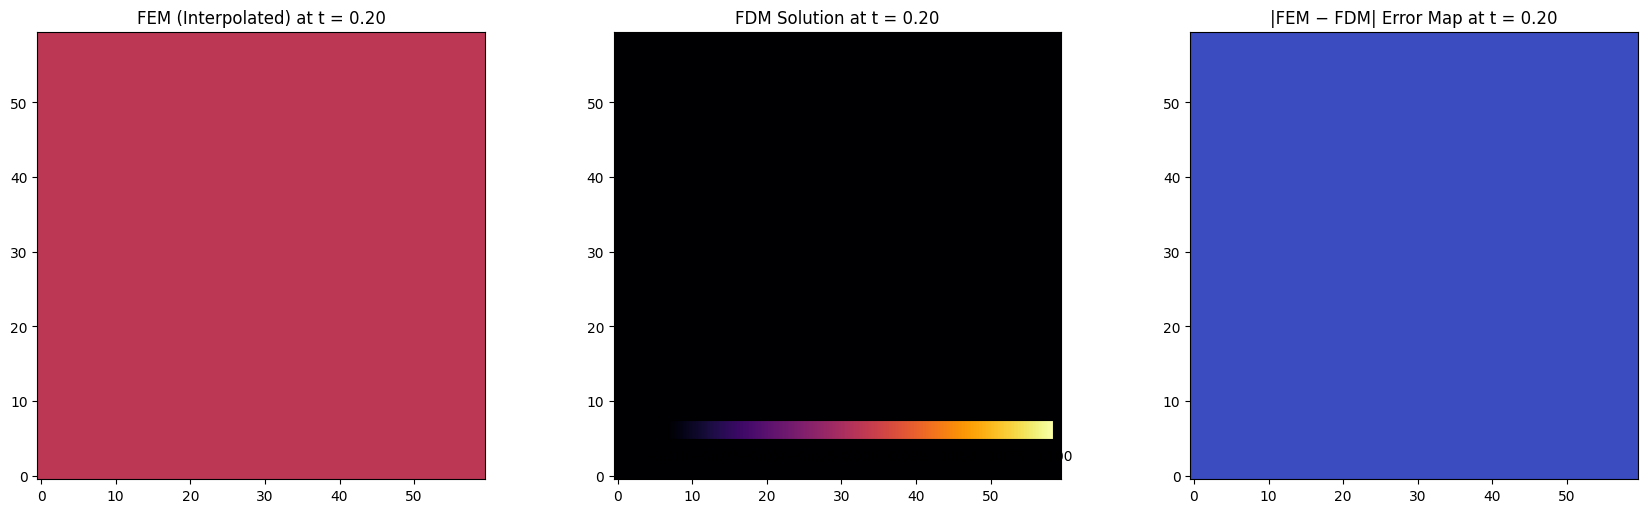

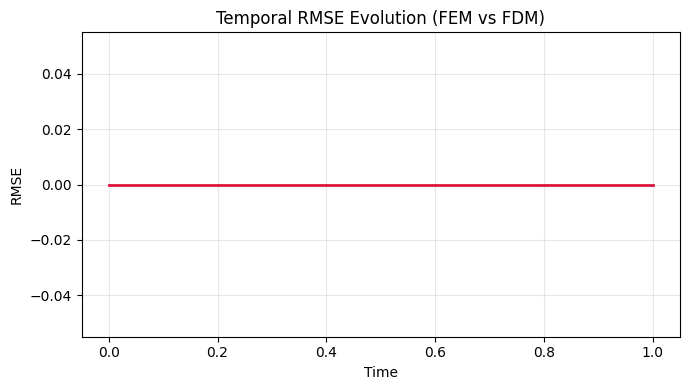

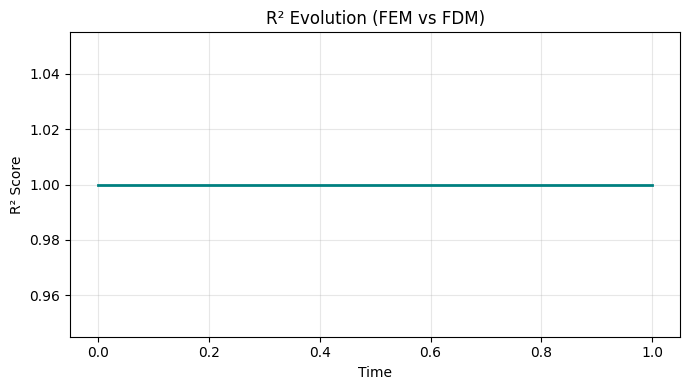

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================
# 0. Select sample and load FEM data
# ==============================================================

sample = 0

U_fem = full_solution[sample]            # (833, 101)
XY_fem = full_solution_mesh              # (833, 2)
t_fem = time_steps                       # (101,)
k = float(k_all[sample])

# ==============================================================
# 1. Interpolate FEM initial condition → FDM grid
# ==============================================================

u0_fem = initial_con[sample]
xy_fem = XY_fem

Nx = Ny = 60
X, Y = np.meshgrid(
    np.linspace(0, 1, Nx),
    np.linspace(0, 1, Ny),
    indexing="ij"
)

u0 = griddata(
    points=xy_fem,
    values=u0_fem,
    xi=np.column_stack([X.ravel(), Y.ravel()]),
    method="linear",
    fill_value=0.0
).reshape(Nx, Ny)

# Apply L-shape mask (Dirichlet BC = 0)
mask = ~((X >= 0.5) & (Y >= 0.5))
u0[~mask] = 0.0

# ==============================================================
# 2. Run FDM solver
# ==============================================================

X, Y, sol_fdm, mask = heat2D_Lshape_solver(
    u0, k, T=1.0, dt=1e-3, Nx=Nx, Ny=Ny
)
t_fdm = np.linspace(0, 1.0, sol_fdm.shape[0])

# ==============================================================
# 3. Interpolate FEM solution → FDM grid at each time step
# ==============================================================

U_fem_interp = np.zeros_like(sol_fdm)
for i, t_curr in enumerate(t_fdm):
    if t_curr <= t_fem[0]:
        U_t = U_fem[:, 0]
    elif t_curr >= t_fem[-1]:
        U_t = U_fem[:, -1]
    else:
        t_idx = np.searchsorted(t_fem, t_curr) - 1
        α = (t_curr - t_fem[t_idx]) / (t_fem[t_idx + 1] - t_fem[t_idx])
        U_t = (1 - α) * U_fem[:, t_idx] + α * U_fem[:, t_idx + 1]

    grid_points = np.column_stack([X.ravel(), Y.ravel()])
    U_interp_flat = griddata(
        points=XY_fem,
        values=U_t,
        xi=grid_points,
        method="linear",
        fill_value=0.0
    )
    U_fem_interp[i] = U_interp_flat.reshape(X.shape)
    U_fem_interp[i][~mask] = 0.0

# ==============================================================
# 4. Compute error metrics across time
# ==============================================================

valid_mask = mask
nt = sol_fdm.shape[0]
rmse_over_time, mae_over_time, relL2_over_time, r2_over_time = [], [], [], []

for i in range(nt):
    fdm_t = sol_fdm[i][valid_mask]
    fem_t = U_fem_interp[i][valid_mask]
    rmse_over_time.append(np.sqrt(mean_squared_error(fem_t, fdm_t)))
    mae_over_time.append(np.mean(np.abs(fem_t - fdm_t)))
    relL2_over_time.append(np.linalg.norm(fdm_t - fem_t) / (np.linalg.norm(fem_t)+1e-12))
    r2_over_time.append(r2_score(fem_t, fdm_t))

rmse_over_time = np.array(rmse_over_time)
mae_over_time = np.array(mae_over_time)
relL2_over_time = np.array(relL2_over_time)
r2_over_time = np.array(r2_over_time)

print("===== FEM vs FDM (Statistics over all times) =====")
print(f"Mean RMSE : {rmse_over_time.mean():.6e}")
print(f"Mean MAE  : {mae_over_time.mean():.6e}")
print(f"Mean Rel L2: {relL2_over_time.mean():.4%}")
print(f"Mean R²   : {r2_over_time.mean():.4f}")

# ==============================================================
# 5. Visualization — at t = 0.2
# ==============================================================

target_time = 0.2
t_idx = np.argmin(np.abs(t_fdm - target_time))
t_actual = t_fdm[t_idx]
print(f"\nPlotting comparison at t ≈ {t_actual:.3f}")

U_fem_plot = U_fem_interp[t_idx]
U_fdm_plot = sol_fdm[t_idx]
U_fem_valid = U_fem_plot[valid_mask]
U_fdm_valid = U_fdm_plot[valid_mask]

vmin = min(U_fem_valid.min(), U_fdm_valid.min())
vmax = max(U_fem_valid.max(), U_fdm_valid.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].imshow(U_fem_plot.T, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[0].set_title(f"FEM (Interpolated) at t = {t_actual:.2f}")

im1 = axes[1].imshow(U_fdm_plot.T, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
axes[1].set_title(f"FDM Solution at t = {t_actual:.2f}")

err_map = np.abs(U_fem_plot - U_fdm_plot)
im2 = axes[2].imshow(err_map.T, origin='lower', cmap='coolwarm')
axes[2].set_title(f"|FEM − FDM| Error Map at t = {t_actual:.2f}")

fig.colorbar(im0, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
plt.tight_layout()
plt.show()

# ==============================================================
# 6. Temporal Error Curves
# ==============================================================

plt.figure(figsize=(7, 4))
plt.plot(t_fdm, rmse_over_time, lw=2, color='crimson')
plt.xlabel("Time")
plt.ylabel("RMSE")
plt.title("Temporal RMSE Evolution (FEM vs FDM)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(t_fdm, r2_over_time, lw=2, color='teal')
plt.xlabel("Time")
plt.ylabel("R² Score")
plt.title("R² Evolution (FEM vs FDM)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
sensor_data.shape

(10000, 40, 11)

In [68]:
import numpy as np
from scipy.sparse import diags, kron, identity, csr_matrix
from scipy.sparse.linalg import spsolve

def heat2D_Lshape_solver(u0, nu, T=1.0, dt=1e-3, Nx=50, Ny=50, 
                                Lx=1.0, Ly=1.0, x_min=-0.5, y_min=-0.5):
    """
    2D heat equation solver on L-shaped domain with custom bounds.
    Domain: [x_min, x_min+Lx] × [y_min, y_min+Ly]
    L-shape: remove top-right corner where x >= x_min+Lx/2 AND y >= y_min+Ly/2
    """
    if hasattr(u0, "device"):
        u0 = np.array(u0)
    if hasattr(nu, "device"):
        nu = float(np.array(nu))
    
    # Grid setup
    dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)
    x = np.linspace(x_min, x_min + Lx, Nx)
    y = np.linspace(y_min, y_min + Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing="ij")
    
    # L-shape mask: remove top-right corner
    x_cutoff = x_min + Lx / 2
    y_cutoff = y_min + Ly / 2
    mask = ~((X >= x_cutoff) & (Y >= y_cutoff))
    
    # Apply mask to initial condition
    u = u0.copy()
    u[~mask] = 0.0
    u[0, :] = u[-1, :] = u[:, 0] = u[:, -1] = 0.0
    
    print(f"Initial condition: min={u.min():.6f}, max={u.max():.6f}, sum={u.sum():.6f}")
    
    num_steps = int(T / dt)
    sol = np.zeros((num_steps + 1, Nx, Ny))
    sol[0] = u.copy()
    
    # Build Laplacian
    Lx_op = diags([np.ones(Nx-1), -2*np.ones(Nx), np.ones(Nx-1)], 
                  [-1, 0, 1], format='csr') / dx**2
    Ly_op = diags([np.ones(Ny-1), -2*np.ones(Ny), np.ones(Ny-1)], 
                  [-1, 0, 1], format='csr') / dy**2
    
    I_x = identity(Nx, format='csr')
    I_y = identity(Ny, format='csr')
    I_full = identity(Nx * Ny, format='csr')
    
    L2D = kron(I_y, Lx_op) + kron(Ly_op, I_x)
    
    # Crank-Nicolson
    theta = 0.5
    A = I_full - theta * nu * dt * L2D
    B = I_full + (1 - theta) * nu * dt * L2D
    
    A = csr_matrix(A)
    B = csr_matrix(B)
    
    u_flat = u.ravel()
    
    # Time stepping
    for n in range(num_steps):
        rhs = B @ u_flat
        u_flat_new = spsolve(A, rhs)
        u_new = u_flat_new.reshape((Nx, Ny))
        
        # Apply boundary conditions
        u_new[~mask] = 0.0
        u_new[0, :] = u_new[-1, :] = u_new[:, 0] = u_new[:, -1] = 0.0
        
        sol[n + 1] = u_new
        u_flat = u_new.ravel()
        
#         if n < 3 or n % 100 == 0:
#             print(f"Step {n+1}: min={u_new.min():.6e}, max={u_new.max():.6e}, sum={u_new.sum():.6e}")
    
    return X, Y, sol, mask


# =====================================================
# Test with debugging
# =====================================================
Nx, Ny = 60, 60
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# Initial condition: Gaussian blob
u0 = np.exp(-80 * ((X - 0.25)**2 + (Y - 0.25)**2))
u0[(X >= 0.5) & (Y >= 0.5)] = 0.0

print(f"u0 before solver: min={u0.min():.6f}, max={u0.max():.6f}")

k = 0.1
X, Y, sol, mask = heat2D_Lshape_solver(u0, k, T=1.0, dt=1e-3, Nx=Nx, Ny=Ny)

print("\nFinal solution stats:")
print(f"sol[0] (t=0): min={sol[0].min():.6f}, max={sol[0].max():.6f}")
print(f"sol[-1] (t=T): min={sol[-1].min():.6f}, max={sol[-1].max():.6f}")

u0 before solver: min=0.000000, max=0.997131
Initial condition: min=0.000000, max=0.997131, sum=136.397015

Final solution stats:
sol[0] (t=0): min=0.000000, max=0.997131
sol[-1] (t=T): min=0.000000, max=0.004501


In [52]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.interpolate import griddata

# ============================================
# 1. SELECT A TEST SAMPLE
# ============================================
sample_idx = 200 # Choose which sample to test

# Get data for this sample
u_data_single = reshaped_sensor_data[sample_idx]  # (40*11)
u_data_single = u_data_single.reshape(1,-1)
actual_k = k_all[sample_idx]
initial_condition_1d = initial_con[sample_idx]  # (833,)

print(f"Testing sample {sample_idx}")
print(f"Actual k: {actual_k:.6f}")

# ============================================
# 2. PREDICT k FROM SENSOR DATA
# ============================================
params_loaded, params_inv = params

k_pred_all = apply_net_k(model_inv_fn, params_inv, u_data_single)
k_mean_raw, k_logstd_raw = k_pred_all[:, 0], k_pred_all[:, 1]
k_mean = jax.nn.softplus(k_mean_raw)
k_std_raw = jnp.exp(k_logstd_raw)
k_std = jnp.minimum(k_std_raw, 0.25 * k_mean)

# Sample k
key = jax.random.PRNGKey(42)
eps = jax.random.normal(key, shape=())
k_sampled = k_mean + eps * k_std
k_sampled = k_sampled[0]
print(f"Predicted k: {k_sampled:.6f}")

# ============================================
# 3. PREPARE INITIAL CONDITION FOR SOLVER
# ============================================
Nx, Ny = 60, 60

# Interpolate from dataset mesh to solver grid
x_grid = np.linspace(0, 1, Nx)
y_grid = np.linspace(0, 1, Ny)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

u0_grid = griddata(
    full_solution_mesh,  # (833, 2) - your mesh coordinates
    initial_condition_1d,  # (833,) - initial values
    (X_grid, Y_grid),
    method='linear',
    fill_value=0.0
)

# Apply L-shape mask
u0_grid[(X_grid >= 0.5) & (Y_grid >= 0.5)] = 0.0

# ============================================
# 4. RUN SOLVER
# ============================================
T = float(sensor_times[-1])
dt = float(sensor_times[1] - sensor_times[0])

X, Y, sol, mask = heat2D_Lshape_solver(
    u0_grid, k_sampled, T=T, dt=dt, Nx=Nx, Ny=Ny
)

print(f"Solver complete. Solution shape: {sol.shape}")

# ============================================
# 5. EXTRACT SOLUTION AT SENSOR LOCATIONS
# ============================================
predicted_sensor_data = np.zeros((40, 11))

# Create grid points for interpolation
grid_points = np.column_stack([X.ravel(), Y.ravel()])

for t_idx, t in enumerate(sensor_times):
    # Find time step in solution
    step_idx = min(int(t / dt), sol.shape[0] - 1)
    sol_t = sol[step_idx]  # (Nx, Ny)
    
    # Interpolate to sensor positions
    predicted_sensor_data[:, t_idx] = griddata(
        grid_points,
        sol_t.ravel(),
        sensor_positions,  # (40, 2)
        method='linear',
        fill_value=0.0
    )

# ============================================
# 6. COMPARE WITH ACTUAL SENSOR DATA
# ============================================
actual_sensor_data = sensor_data[sample_idx]  # (40, 11)

print(predicted_sensor_data.shape)
print(actual_sensor_data.shape)

# Compute errors
abs_error = np.abs(predicted_sensor_data - actual_sensor_data)
rel_error = abs_error / (np.abs(actual_sensor_data) + 1e-8)

rmse = np.sqrt(np.mean(abs_error**2))
max_error = np.max(abs_error)
mean_rel_error = np.mean(rel_error)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"RMSE at sensors: {rmse:.8f}")
print(f"Max absolute error: {max_error:.8f}")
print(f"Mean relative error: {mean_rel_error:.4%}")
print(f"\nk error: {abs(k_sampled - actual_k):.8f}")
print(f"k relative error: {abs(k_sampled - actual_k)/actual_k:.4%}")

# Optional: Plot comparison at a few sensors
print("\nSample sensor comparisons:")
for i in [0, 10, 20, 30]:
    print(f"Sensor {i}: Predicted={predicted_sensor_data[i, -1]:.6f}, "
          f"Actual={actual_sensor_data[i, -1]:.6f}")

Testing sample 200
Actual k: 0.013838
Predicted k: 0.090551
Initial condition: min=0.000000, max=0.000000, sum=0.000000
Step 1: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 2: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 3: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Solver complete. Solution shape: (10, 60, 60)
(40, 11)
(40, 11)

RESULTS
RMSE at sensors: 0.09253132
Max absolute error: 0.48899385
Mean relative error: 40.0000%

k error: 0.07671227
k relative error: 554.3441%

Sample sensor comparisons:
Sensor 0: Predicted=0.000000, Actual=0.000000
Sensor 10: Predicted=0.000000, Actual=0.000000
Sensor 20: Predicted=0.000000, Actual=0.106966
Sensor 30: Predicted=0.000000, Actual=0.024707


In [64]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.interpolate import griddata

# ============================================
# 1. SELECT A TEST SAMPLE
# ============================================
sample_idx = 200
u_data_single = reshaped_sensor_data[sample_idx]
u_data_single = u_data_single.reshape(1,-1)
actual_k = k_all[sample_idx]
initial_condition_1d = initial_con[sample_idx]

print(f"Testing sample {sample_idx}")
print(f"Actual k: {actual_k:.6f}")

# ============================================
# 2. PREDICT k FROM SENSOR DATA
# ============================================
params_loaded, params_inv = params
k_pred_all = apply_net_k(model_inv_fn, params_inv, u_data_single)
k_mean_raw, k_logstd_raw = k_pred_all[:, 0], k_pred_all[:, 1]
k_mean = jax.nn.softplus(k_mean_raw)
k_std_raw = jnp.exp(k_logstd_raw)
k_std = jnp.minimum(k_std_raw, 0.25 * k_mean)

key = jax.random.PRNGKey(42)
eps = jax.random.normal(key, shape=())
k_sampled = k_mean + eps * k_std
k_sampled = k_sampled[0]
print(f"Predicted k: {k_sampled:.6f}")

# ============================================
# 3. PREPARE INITIAL CONDITION FOR SOLVER
# ============================================
Nx, Ny = 60, 60
x_grid = np.linspace(0, 1, Nx)
y_grid = np.linspace(0, 1, Ny)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

u0_grid = griddata(
    full_solution_mesh,
    initial_condition_1d,
    (X_grid, Y_grid),
    method='linear',
    fill_value=0.0
)

# Apply L-shape mask
u0_grid[(X_grid >= 0.5) & (Y_grid >= 0.5)] = 0.0

print(f"Initial condition: min={u0_grid.min():.6f}, max={u0_grid.max():.6f}")

# ============================================
# 4. RUN SOLVER WITH SMALL dt
# ============================================
T = float(sensor_times[-1])
dt_solver = 1e-3  # Small timestep for stability
print(f"Solver: T={T}, dt={dt_solver}, sensor_times={sensor_times}")

X, Y, sol, mask = heat2D_Lshape_solver(
    u0_grid, k_sampled, T=T, dt=dt_solver, Nx=Nx, Ny=Ny
)
print(f"Solver complete. Solution shape: {sol.shape}")
print(f"Solution range: [{sol.min():.6f}, {sol.max():.6f}]")

# ============================================
# 5. EXTRACT SOLUTION AT SENSOR LOCATIONS AND TIMES
# ============================================
predicted_sensor_data = np.zeros((40, len(sensor_times)))

# Mask for valid domain (exclude cut-out region)
valid_mask = ~((X >= 0.5) & (Y >= 0.5))
valid_grid_points = np.column_stack([X[valid_mask].ravel(), Y[valid_mask].ravel()])

for t_idx, t in enumerate(sensor_times):
    # Find closest time step in solution
    step_idx = int(np.round(t / dt_solver))
    step_idx = min(step_idx, sol.shape[0] - 1)
    
    sol_t = sol[step_idx]  # (Nx, Ny)
    
    # Use only valid (non-masked) solution values
    valid_sol_values = sol_t[valid_mask].ravel()
    
    # Interpolate to sensor positions
    predicted_sensor_data[:, t_idx] = griddata(
        valid_grid_points,
        valid_sol_values,
        sensor_positions,
        method='linear',
        fill_value=0.0
    )
    
#     print(f"Time {t:.3f} (step {step_idx}): sol range=[{sol_t.min():.6f}, {sol_t.max():.6f}], "
#           f"predicted range=[{predicted_sensor_data[:, t_idx].min():.6f}, {predicted_sensor_data[:, t_idx].max():.6f}]")

# ============================================
# 6. COMPARE WITH ACTUAL SENSOR DATA
# ============================================
actual_sensor_data = sensor_data[sample_idx]

print(f"\nPredicted shape: {predicted_sensor_data.shape}")
print(f"Actual shape: {actual_sensor_data.shape}")

# Compute errors
abs_error = np.abs(predicted_sensor_data - actual_sensor_data)
rel_error = abs_error / (np.abs(actual_sensor_data) + 1e-8)
rmse = np.sqrt(np.mean(abs_error**2))
max_error = np.max(abs_error)
mean_rel_error = np.mean(rel_error)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"RMSE at sensors: {rmse:.8f}")
print(f"Max absolute error: {max_error:.8f}")
print(f"Mean relative error: {mean_rel_error:.4%}")
print(f"\nk error: {abs(k_sampled - actual_k):.8f}")
print(f"k relative error: {abs(k_sampled - actual_k)/actual_k:.4%}")

# Optional: Plot comparison at a few sensors
print("\nSample sensor comparisons:")
for i in [0, 10, 20, 30]:
    print(f"Sensor {i}: Predicted={predicted_sensor_data[i, -1]:.6f}, "
          f"Actual={actual_sensor_data[i, -1]:.6f}")

Testing sample 200
Actual k: 0.013838
Predicted k: 0.090551
Initial condition: min=0.000000, max=0.000000
Solver: T=1.0, dt=0.001, sensor_times=[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Initial condition: min=0.000000, max=0.000000, sum=0.000000
Step 1: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 2: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 3: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 101: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 201: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 301: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00
Step 401: min=0.000000e+00, max=0.000000e+00, sum=0.000000e+00


KeyboardInterrupt: 

In [54]:
sensor_times[-1]

Array(1., dtype=float32)

In [55]:
dt

0.10000000149011612

In [59]:
u0_grid.shape

(60, 60)

In [58]:
np.max(initial_condition_1d), np.max(u0_grid)

(Array(0.57016385, dtype=float32), 0.0)

In [40]:
k_sampled

Array(0.09055065, dtype=float32)

In [69]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.interpolate import griddata

# ============================================
# 1. SELECT A TEST SAMPLE
# ============================================
sample_idx = 20
u_data_single = reshaped_sensor_data[sample_idx]
u_data_single = u_data_single.reshape(1,-1)
actual_k = k_all[sample_idx]
initial_condition_1d = initial_con[sample_idx]

print(f"Testing sample {sample_idx}")
print(f"Actual k: {actual_k:.6f}")
print(f"Initial condition range: [{initial_condition_1d.min():.6f}, {initial_condition_1d.max():.6f}]")

# ============================================
# 2. PREDICT k FROM SENSOR DATA
# ============================================
params_loaded, params_inv = params
k_pred_all = apply_net_k(model_inv_fn, params_inv, u_data_single)
k_mean_raw, k_logstd_raw = k_pred_all[:, 0], k_pred_all[:, 1]
k_mean = jax.nn.softplus(k_mean_raw)
k_std_raw = jnp.exp(k_logstd_raw)
k_std = jnp.minimum(k_std_raw, 0.25 * k_mean)

key = jax.random.PRNGKey(42)
eps = jax.random.normal(key, shape=())
k_sampled = k_mean + eps * k_std
k_sampled = float(k_sampled[0])
print(f"Predicted k: {k_sampled:.6f}")

# ============================================
# 3. PREPARE INITIAL CONDITION FOR SOLVER
# ============================================
Nx, Ny = 60, 60

# Create grid in [-0.5, 0.5] to match the data
x_grid = np.linspace(-0.5, 0.5, Nx)
y_grid = np.linspace(-0.5, 0.5, Ny)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

print(f"Target grid range: X=[{X_grid.min():.2f}, {X_grid.max():.2f}], Y=[{Y_grid.min():.2f}, {Y_grid.max():.2f}]")

# Interpolate from data mesh to solver grid
u0_grid = griddata(
    full_solution_mesh,      # (833, 2) in [-0.5, 0.5]
    initial_condition_1d,    # (833,)
    (X_grid, Y_grid),       # (60, 60) in [-0.5, 0.5]
    method='linear',
    fill_value=0.0
)

print(f"u0_grid after interpolation: min={u0_grid.min():.6f}, max={u0_grid.max():.6f}, mean={u0_grid.mean():.6f}")

# Apply L-shape mask (remove top-right corner: x >= 0 AND y >= 0)
u0_grid[(X_grid >= 0.0) & (Y_grid >= 0.0)] = 0.0

# Apply boundary conditions
u0_grid[0, :] = 0.0
u0_grid[-1, :] = 0.0
u0_grid[:, 0] = 0.0
u0_grid[:, -1] = 0.0

print(f"u0_grid after mask: min={u0_grid.min():.6f}, max={u0_grid.max():.6f}, mean={u0_grid.mean():.6f}")

# ============================================
# 4. RUN SOLVER (need to update solver for [-0.5, 0.5] domain)
# ============================================
T = float(sensor_times[-1])
dt_solver = 1e-3
print(f"\nSolver: T={T}, dt={dt_solver}")

# Update the solver call to use the correct domain
X, Y, sol, mask = heat2D_Lshape_solver(
    u0_grid, k_sampled, T=T, dt=dt_solver, Nx=Nx, Ny=Ny,
    Lx=1.0, Ly=1.0, x_min=-0.5, y_min=-0.5  # Domain is [-0.5, 0.5]
)
print(f"Solver complete. Solution shape: {sol.shape}")
print(f"Solution range: [{sol.min():.6f}, {sol.max():.6f}]")

# ============================================
# 5. EXTRACT SOLUTION AT SENSOR LOCATIONS
# ============================================
predicted_sensor_data = np.zeros((40, len(sensor_times)))

print(f"Sensor positions range: X=[{sensor_positions[:, 0].min():.2f}, {sensor_positions[:, 0].max():.2f}], "
      f"Y=[{sensor_positions[:, 1].min():.2f}, {sensor_positions[:, 1].max():.2f}]")

# Mask for valid domain (exclude top-right corner)
valid_mask = ~((X >= 0.0) & (Y >= 0.0))
valid_grid_points = np.column_stack([X[valid_mask].ravel(), Y[valid_mask].ravel()])

for t_idx, t in enumerate(sensor_times):
    step_idx = int(np.round(t / dt_solver))
    step_idx = min(step_idx, sol.shape[0] - 1)
    
    sol_t = sol[step_idx]
    valid_sol_values = sol_t[valid_mask].ravel()
    
    predicted_sensor_data[:, t_idx] = griddata(
        valid_grid_points,
        valid_sol_values,
        sensor_positions,  # Should already be in [-0.5, 0.5]
        method='linear',
        fill_value=0.0
    )

# ============================================
# 6. COMPARE WITH ACTUAL SENSOR DATA
# ============================================
actual_sensor_data = sensor_data[sample_idx]

abs_error = np.abs(predicted_sensor_data - actual_sensor_data)
rel_error = abs_error / (np.abs(actual_sensor_data) + 1e-8)
rmse = np.sqrt(np.mean(abs_error**2))
max_error = np.max(abs_error)
mean_rel_error = np.mean(rel_error)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"RMSE at sensors: {rmse:.8f}")
print(f"Max absolute error: {max_error:.8f}")
print(f"Mean relative error: {mean_rel_error:.4%}")
print(f"\nk error: {abs(k_sampled - actual_k):.8f}")
print(f"k relative error: {abs(k_sampled - actual_k)/actual_k:.4%}")

print("\nSample sensor comparisons:")
for i in [0, 10, 20, 30]:
    print(f"Sensor {i}: Predicted={predicted_sensor_data[i, -1]:.6f}, "
          f"Actual={actual_sensor_data[i, -1]:.6f}")

Testing sample 20
Actual k: 0.010000
Initial condition range: [-0.208638, 0.778157]
Predicted k: 0.090338
Target grid range: X=[-0.50, 0.50], Y=[-0.50, 0.50]
u0_grid after interpolation: min=-0.205039, max=0.775514, mean=0.145325
u0_grid after mask: min=-0.205039, max=0.775514, mean=0.145325

Solver: T=1.0, dt=0.001
Initial condition: min=-0.205039, max=0.775514, sum=523.170679
Solver complete. Solution shape: (1001, 60, 60)
Solution range: [-0.205039, 0.775514]
Sensor positions range: X=[-0.50, 0.50], Y=[-0.50, 0.50]

RESULTS
RMSE at sensors: 0.13211106
Max absolute error: 0.45860243
Mean relative error: 11487245.3125%

k error: 0.08033795
k relative error: 803.3795%

Sample sensor comparisons:
Sensor 0: Predicted=0.000000, Actual=0.000000
Sensor 10: Predicted=0.000000, Actual=0.000000
Sensor 20: Predicted=0.004327, Actual=0.108200
Sensor 30: Predicted=0.010055, Actual=0.152163


In [72]:
actual_sensor_data.shape, predicted_sensor_data.shape

((40, 11), (40, 11))

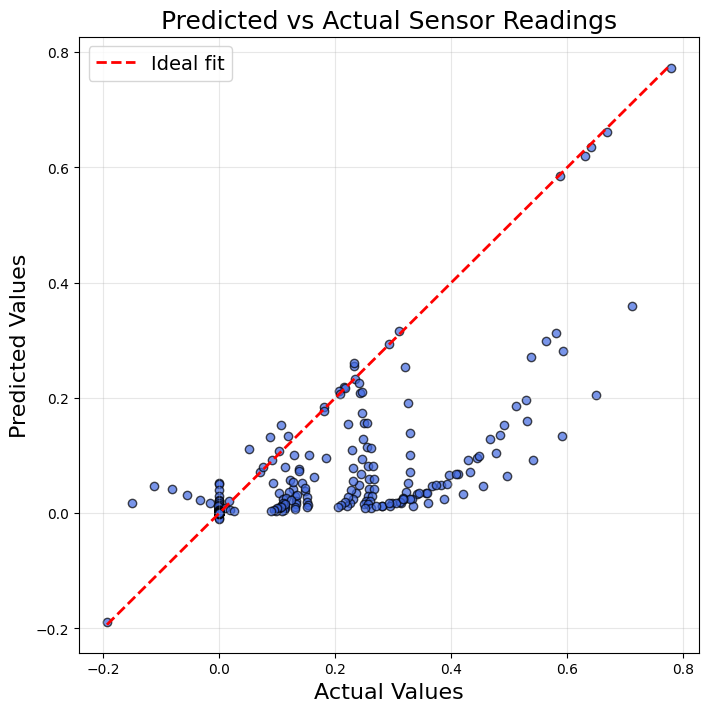

In [70]:
import matplotlib.pyplot as plt

# Flatten both arrays for comparison
y_true = actual_sensor_data.flatten()
y_pred = predicted_sensor_data.flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, c='royalblue', alpha=0.7, edgecolor='k')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Ideal fit')

plt.title("Predicted vs Actual Sensor Readings", fontsize=18)
plt.xlabel("Actual Values", fontsize=16)
plt.ylabel("Predicted Values", fontsize=16)
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
params = load_model_params(result_dir, filename='model_params_best.pkl')

loss_test, l2_error, s_pred, k_pred, abs_err_k = loss_test_l2_error(model_fn, model_inv_fn, params, X_test, y_test, full_solution_coordinates, k_test, return_data=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator, ScalarFormatter

def get_masked_lshape_triangulation(x, y):
    triang = tri.Triangulation(x, y)
    xmid = x[triang.triangles].mean(axis=1)
    ymid = y[triang.triangles].mean(axis=1)
    mask = np.logical_or(xmid < 0, ymid < 0)
    triang.set_mask(~mask)
    return triang

sample_idx = 1980#1811# 1883
x = full_solution_coordinates[:, 0]
y = full_solution_coordinates[:, 1]
t = full_solution_coordinates[:, 2]

k_val = k_test[sample_idx]
k_pred_val = k_pred[sample_idx]

pred = s_pred[sample_idx]
gt = y_test[sample_idx]
error = np.abs(pred - gt)

vmin = min(pred.min(), gt.min())
vmax = max(pred.max(), gt.max())
err_min = error.min()
err_max = error.max()

unique_times = np.unique(t)
n_plot = min(4, len(unique_times))
plot_times = unique_times[np.linspace(0, len(unique_times)-1, n_plot, dtype=int)]

for i, time_val in enumerate(plot_times):
    mask = t == time_val

    x_t, y_t = x[mask], y[mask]
    gt_t = gt[mask]
    pred_t = pred[mask]
    err_t = error[mask]

    triang = get_masked_lshape_triangulation(x_t, y_t)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.3})

    # FEM
    cont_gt = axes[0].tricontourf(triang, gt_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    # axes[0].set_title("FEM: T", fontsize=12)
    axes[0].set_title(f"FEM: T (k = {k_val:.3f})", fontsize=12)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect('equal')

    # Prediction
    cont_pred = axes[1].tricontourf(triang, pred_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    axes[1].set_title(f"t = {time_val:.3f}\nPredicted: T (k_pred = {k_pred_val:.3f})", fontsize=12)
    axes[1].set_xlabel("x")
    axes[1].set_yticks([])
    axes[1].set_aspect('equal')

    # Error
    cont_err = axes[2].tricontourf(triang, err_t, cmap='magma', vmin=err_min, vmax=err_max, levels=100)
    axes[2].set_title("Absolute Error", fontsize=12)
    axes[2].set_xlabel("x")
    axes[2].set_yticks([])
    axes[2].set_aspect('equal')

    # Temperature colorbar below FEM + Predicted
    cax_temp = inset_axes(axes[1], width="190%", height="5%", loc='lower center',
                          bbox_to_anchor=(-0.65, -0.35, 1, 1),
                          bbox_transform=axes[1].transAxes, borderpad=0)
    cbar1 = fig.colorbar(cont_pred, cax=cax_temp, orientation='horizontal')
    cbar1.set_label("Temperature", fontsize=10)
    cbar1.locator = MaxNLocator(nbins=6)
    cbar1.update_ticks()

    # Error colorbar below Absolute Error
    cax_err = inset_axes(axes[2], width="90%", height="5%", loc='lower center',
                         bbox_to_anchor=(0, -0.35, 1, 1),
                         bbox_transform=axes[2].transAxes, borderpad=0)
    cbar2 = fig.colorbar(cont_err, cax=cax_err, orientation='horizontal')
    cbar2.set_label("|Error|", fontsize=10)
    cbar2.locator = MaxNLocator(nbins=5)
    cbar2.formatter = ScalarFormatter(useMathText=True)
    cbar2.formatter.set_powerlimits((-2, 2))
    cbar2.update_ticks()
    
    if time_val in sensor_times:
        for j in range(3):
            if j<2:
                axes[j].scatter(sensor_positions[:, 0], sensor_positions[:, 1],
                    color='black', marker='x', s=30, label='Sensors')
            else:
                axes[j].scatter(sensor_positions[:, 0], sensor_positions[:, 1],
                    color='white', marker='x', s=30, label='Sensors')
    



    plt.tight_layout()
    plt.show()

In [28]:
sensor_positions.shape

(40, 2)

/tmp/ipykernel_2222286/3814357898.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


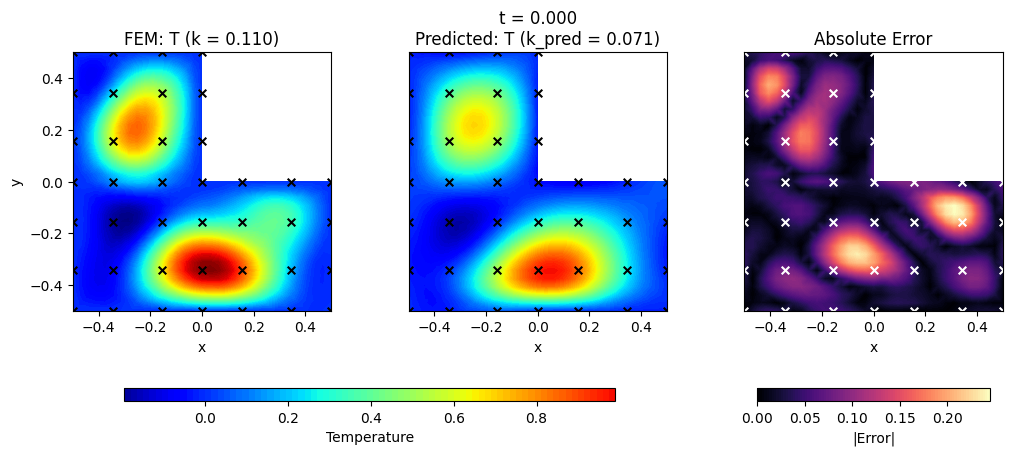

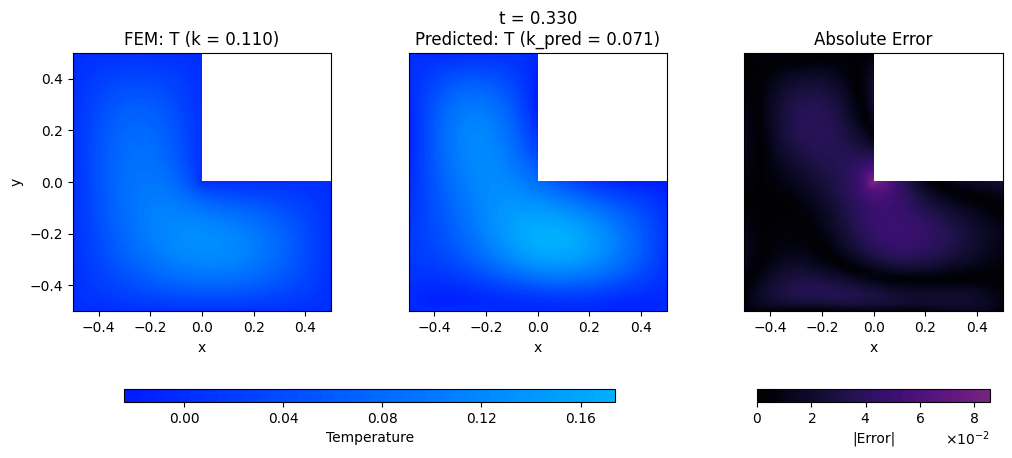

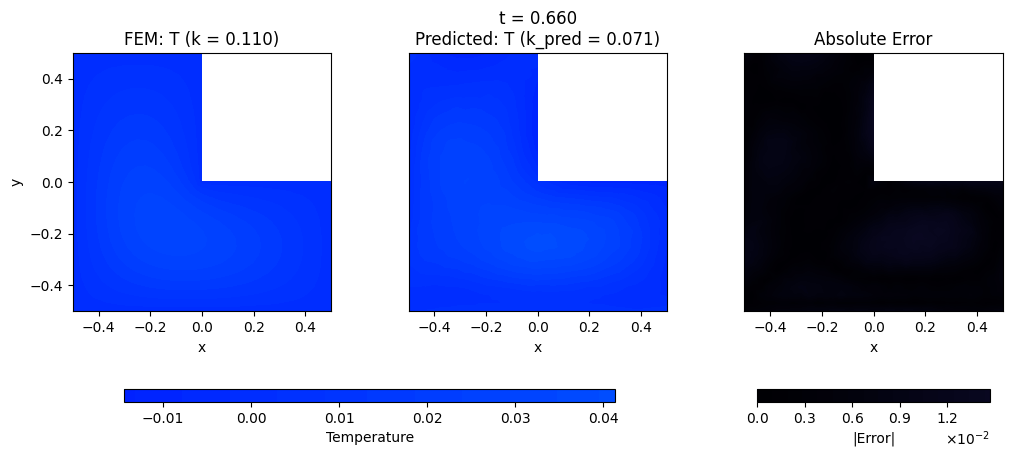

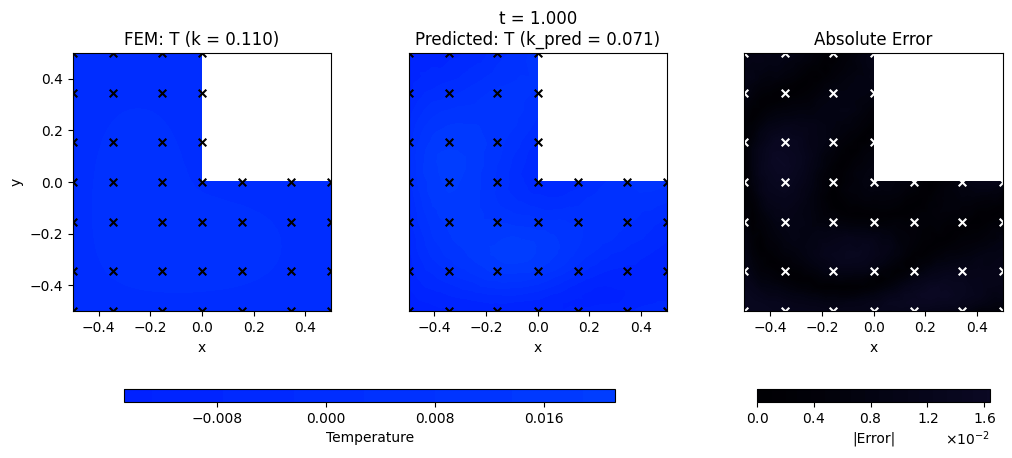

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator, ScalarFormatter

def get_masked_lshape_triangulation(x, y):
    triang = tri.Triangulation(x, y)
    xmid = x[triang.triangles].mean(axis=1)
    ymid = y[triang.triangles].mean(axis=1)
    mask = np.logical_or(xmid < 0, ymid < 0)
    triang.set_mask(~mask)
    return triang

sample_idx = 1823#1811# 1883
x = full_solution_coordinates[:, 0]
y = full_solution_coordinates[:, 1]
t = full_solution_coordinates[:, 2]

k_val = k_test[sample_idx]
k_pred_val = k_pred[sample_idx]

pred = s_pred[sample_idx]
gt = y_test[sample_idx]
error = np.abs(pred - gt)

vmin = min(pred.min(), gt.min())
vmax = max(pred.max(), gt.max())
err_min = error.min()
err_max = error.max()

unique_times = np.unique(t)
n_plot = min(4, len(unique_times))
plot_times = unique_times[np.linspace(0, len(unique_times)-1, n_plot, dtype=int)]

for i, time_val in enumerate(plot_times):
    mask = t == time_val

    x_t, y_t = x[mask], y[mask]
    gt_t = gt[mask]
    pred_t = pred[mask]
    err_t = error[mask]

    triang = get_masked_lshape_triangulation(x_t, y_t)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.3})

    # FEM
    cont_gt = axes[0].tricontourf(triang, gt_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    # axes[0].set_title("FEM: T", fontsize=12)
    axes[0].set_title(f"FEM: T (k = {k_val:.3f})", fontsize=12)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect('equal')

    # Prediction
    cont_pred = axes[1].tricontourf(triang, pred_t, cmap='jet', vmin=vmin, vmax=vmax, levels=100)
    axes[1].set_title(f"t = {time_val:.3f}\nPredicted: T (k_pred = {k_pred_val:.3f})", fontsize=12)
    axes[1].set_xlabel("x")
    axes[1].set_yticks([])
    axes[1].set_aspect('equal')

    # Error
    cont_err = axes[2].tricontourf(triang, err_t, cmap='magma', vmin=err_min, vmax=err_max, levels=100)
    axes[2].set_title("Absolute Error", fontsize=12)
    axes[2].set_xlabel("x")
    axes[2].set_yticks([])
    axes[2].set_aspect('equal')

    # Temperature colorbar below FEM + Predicted
    cax_temp = inset_axes(axes[1], width="190%", height="5%", loc='lower center',
                          bbox_to_anchor=(-0.65, -0.35, 1, 1),
                          bbox_transform=axes[1].transAxes, borderpad=0)
    cbar1 = fig.colorbar(cont_pred, cax=cax_temp, orientation='horizontal')
    cbar1.set_label("Temperature", fontsize=10)
    cbar1.locator = MaxNLocator(nbins=6)
    cbar1.update_ticks()

    # Error colorbar below Absolute Error
    cax_err = inset_axes(axes[2], width="90%", height="5%", loc='lower center',
                         bbox_to_anchor=(0, -0.35, 1, 1),
                         bbox_transform=axes[2].transAxes, borderpad=0)
    cbar2 = fig.colorbar(cont_err, cax=cax_err, orientation='horizontal')
    cbar2.set_label("|Error|", fontsize=10)
    cbar2.locator = MaxNLocator(nbins=5)
    cbar2.formatter = ScalarFormatter(useMathText=True)
    cbar2.formatter.set_powerlimits((-2, 2))
    cbar2.update_ticks()
    
    if time_val in sensor_times:
        for j in range(3):
            if j<2:
                axes[j].scatter(sensor_positions[:, 0], sensor_positions[:, 1],
                    color='black', marker='x', s=30, label='Sensors')
            else:
                axes[j].scatter(sensor_positions[:, 0], sensor_positions[:, 1],
                    color='white', marker='x', s=30, label='Sensors')
    



    plt.tight_layout()
    plt.show()

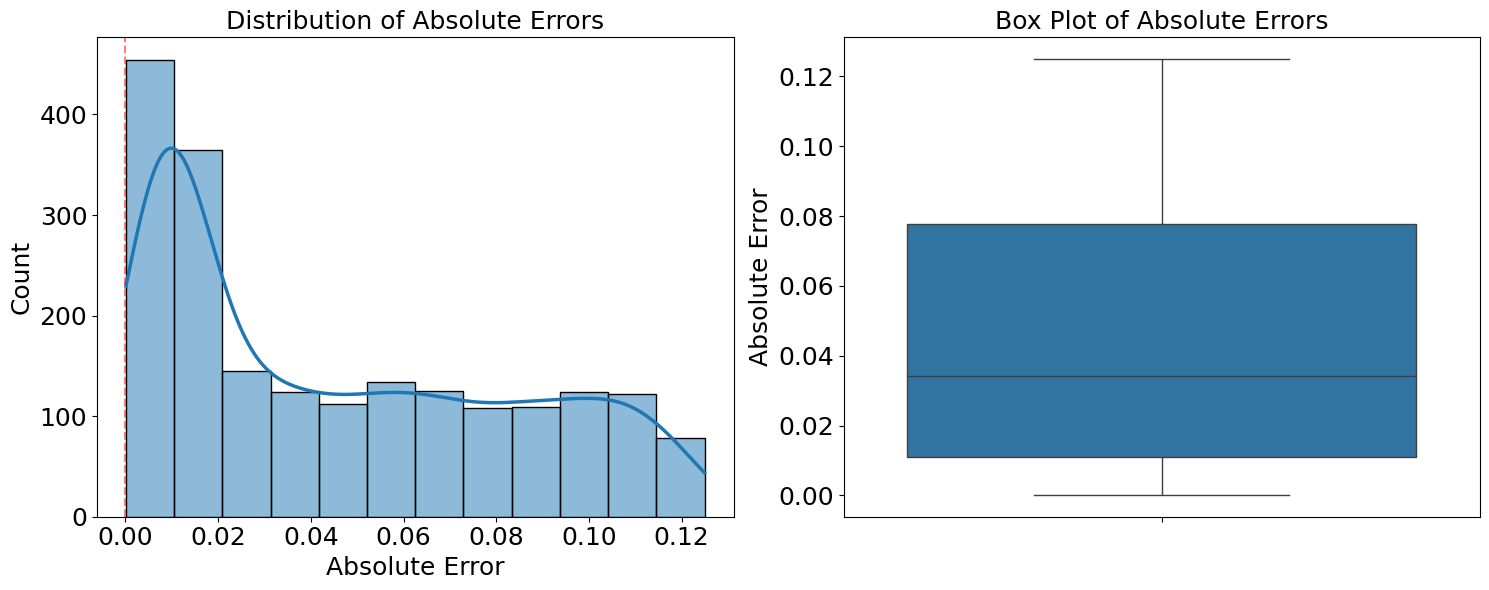


Error Distribution Statistics:
------------------------------
Mean Error: 0.045
Median Error: 0.034
Standard Deviation: 0.038
Minimum: 0.000
Maximum: 0.125

Outlier Analysis:
------------------------------
Number of outliers: 0
Percentage of outliers: 0.00%


In [27]:
import seaborn as sns

def plot_error_distribution(rel_err_nu):
    """
    Create a side-by-side visualization of the error distribution

    Parameters:
    rel_err_nu: numpy array containing relative errors
    """
    # Create a figure with side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Histogram with KDE
    sns.histplot(rel_err_nu.flatten(), kde=True, line_kws=dict(linewidth=2.5),ax=ax1)
    ax1.set_title('Distribution of Absolute Errors', fontsize=18)
    ax1.set_xlabel('Absolute Error', fontsize=18)
    ax1.set_ylabel('Count', fontsize=18)
    ax1.axvline(x=0, color='r', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='both', which='major', labelsize=18)

    # Plot 2: Box plot
    sns.boxplot(y=rel_err_nu.flatten(), ax=ax2)
    ax2.set_title('Box Plot of Absolute Errors', fontsize=18)
    ax2.set_ylabel('Absolute Error', fontsize=18)
    ax2.tick_params(axis='both', which='major', labelsize=18)

    # Adjust layout and display
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f'abs_error_D.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

    # Calculate and print statistics
    print("\nError Distribution Statistics:")
    print("-" * 30)
    print(f"Mean Error: {np.mean(rel_err_nu):.3f}")
    print(f"Median Error: {np.median(rel_err_nu):.3f}")
    print(f"Standard Deviation: {np.std(rel_err_nu):.3f}")
    print(f"Minimum: {np.min(rel_err_nu):.3f}")
    print(f"Maximum: {np.max(rel_err_nu):.3f}")

    # Calculate and print outlier information
    q1 = np.percentile(rel_err_nu, 25)
    q3 = np.percentile(rel_err_nu, 75)
    iqr = q3 - q1
    outliers = rel_err_nu[(rel_err_nu < (q1 - 1.5 * iqr)) | (rel_err_nu > (q3 + 1.5 * iqr))]
    print("\nOutlier Analysis:")
    print("-" * 30)
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers)/len(rel_err_nu)*100):.2f}%")

# Example usage:
plot_error_distribution(abs_err_k)

In [22]:
abs_err_k = np.array(abs_err_k)  # ensure it's a NumPy array
lowest_indices = np.argsort(abs_err_k)[:300]  # indices of 5 lowest values

print("Indices of 5 lowest values:", lowest_indices)
print("Corresponding values:", abs_err_k[lowest_indices])

Indices of 5 lowest values: [1823  582  831 1719  155 1431  148 1207 1843 1115 1010  564 1035 1779
 1983  913 1119 1884 1121    2 1725 1968 1106  585  961   55  566  867
  174  741  530  695 1634  332 1441 1697  553  802 1660   34  191  671
  357 1595 1966   17  886  834  654  549  397 1012  920  115  979  804
 1419  419  264  554  135 1286  447  857 1668  482  233  242 1881 1144
 1583   48  829 1005 1931 1998 1867 1847 1250  706  112 1027 1802  313
   73  559 1909 1070 1594 1440  317  370 1928 1585 1917 1675 1249  103
 1997  606 1523 1093 1452   82 1108 1678  659 1806 1458  890 1162  245
  658 1190 1165 1695 1240  302 1277 1170  670  390 1592 1751 1085  134
 1504  336  568  237  337  268  109 1244 1257 1020 1571  694  311 1068
  259 1860 1635 1270  198  693 1934  576 1846  461 1814   75 1337  650
 1048  780 1122 1894  781 1223  153 1057  965  980  885 1137 1985 1426
 1123  936  433  666 1127  969  957 1065 1920 1876  704 1470 1822 1468
  914 1730 1852 1858  636 1014  858 1421 1364 134

In [22]:
import diffusion_env

ModuleNotFoundError: No module named 'diffusion_env'